# Introduction to financial technical analysis

# 📌 Objectives

By the end of this notebook, students will be able to:

1. **Access and Manipulate Financial Data:**
   - Use the `yfinance` library to retrieve historical stock prices for all companies in the S&P 500 index.

2. **Compute Key Technical Indicators:**
   - Calculate 50-day and 200-day moving averages for each stock in the index.

3. **Detect Trading Signals:**
   - Identify Golden Crosses and Death Crosses as described in technical analysis literature.

4. **Analyze Recent Market Behavior:**
   - Isolate and examine stocks that experienced technical signals (crosses) in the last 14 days.

5. **Visualize Price Trends and Volatility:**
   - Plot historical price movements along with moving averages, and compute volatility around signal dates.

6. **Interpret Technical Indicators in Context:**
   - Reflect on what Golden and Death Crosses signify and how traders may respond to them.

7. **Evaluate Strategy Viability:**
   - Discuss the strengths and limitations of using moving averages as a standalone trading strategy.

8. **Connect Technical Analysis to Broader Market Intelligence:**
   - Explore how sentiment analysis and news (covered in later sections) could complement technical signals.

9. **Develop Critical Thinking About Signal Reliability:**
   - Assess potential risks of false positives and propose improvements or filters to enhance signal accuracy.

10. **Engage in Strategic Reflection:**
    - Answer analytical questions aimed at understanding the utility, risks, and presentation of the strategy to a professional audience.


## Import and install librairies

In [ ]:
%pip install pandas
%pip install yfinance
%pip install lxml
%pip install matplotlib


In [ ]:
import yfinance as yf
import pandas as pd
import requests
from bs4 import BeautifulSoup
import re
import matplotlib.pyplot as plt
import numpy as np



## Get the list of stocks in the S&P 500

In [ ]:
# Read and print the stock tickers that make up S&P500
df_tickers = pd.read_html(
    'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies')[0]
print(df_tickers.head())

  Symbol             Security             GICS Sector  \
0    MMM                   3M             Industrials   
1    AOS          A. O. Smith             Industrials   
2    ABT  Abbott Laboratories             Health Care   
3   ABBV               AbbVie             Health Care   
4    ACN            Accenture  Information Technology   

                GICS Sub-Industry    Headquarters Location  Date added  \
0        Industrial Conglomerates    Saint Paul, Minnesota  1957-03-04   
1               Building Products     Milwaukee, Wisconsin  2017-07-26   
2           Health Care Equipment  North Chicago, Illinois  1957-03-04   
3                   Biotechnology  North Chicago, Illinois  2012-12-31   
4  IT Consulting & Other Services          Dublin, Ireland  2011-07-06   

       CIK      Founded  
0    66740         1902  
1    91142         1916  
2     1800         1888  
3  1551152  2013 (1888)  
4  1467373         1989  


In [ ]:
display(df_tickers)

,Symbol,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,CIK,Founded
0,MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,66740,1902
1,AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,91142,1916
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,"North Chicago, Illinois",1957-03-04,1800,1888
3,ABBV,AbbVie,Health Care,Biotechnology,"North Chicago, Illinois",2012-12-31,1551152,2013 (1888)
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1467373,1989
...,...,...,...,...,...,...,...,...
498,XYL,Xylem Inc.,Industrials,Industrial Machinery & Supplies & Components,"White Plains, New York",2011-11-01,1524472,2011
499,YUM,Yum! Brands,Consumer Discretionary,Restaurants,"Louisville, Kentucky",1997-10-06,1041061,1997
500,ZBRA,Zebra Technologies,Information Technology,Electronic Equipment & Instruments,"Lincolnshire, Illinois",2019-12-23,877212,1969
501,ZBH,Zimmer Biomet,Health Care,Health Care Equipment,"Warsaw, Indiana",2001-08-07,1136869,1927


In [ ]:
ticker_list = df_tickers['Symbol'].tolist()

## Get the closing price of all 500 stocks in the S&P 500 Index
Use the yfinance library to retrieve the close price of all 500 stocks in the index between 2024-05-01 and 2025-05-01
https://ranaroussi.github.io/yfinance/reference/yfinance.stock.html

In [ ]:
start_date = '2024-05-01'
end_date = '2025-05-01'

In [ ]:
# CODE HERE
# Use as many coding cells as you need
df_tickers['GICS Sector'].unique()
# Load closing prices
# Make sure you end this coding section by displaying your results: display(df_close)

array(['Industrials', 'Health Care', 'Information Technology',
       'Utilities', 'Financials', 'Materials', 'Consumer Discretionary',
       'Real Estate', 'Communication Services', 'Consumer Staples',
       'Energy'], dtype=object)

In [ ]:
df_tickers.query('`GICS Sector` == "Communication Services"')

,Symbol,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,CIK,Founded
19,GOOGL,Alphabet Inc. (Class A),Communication Services,Interactive Media & Services,"Mountain View, California",2014-04-03,1652044,1998
20,GOOG,Alphabet Inc. (Class C),Communication Services,Interactive Media & Services,"Mountain View, California",2006-04-03,1652044,1998
46,T,AT&T,Communication Services,Integrated Telecommunication Services,"Dallas, Texas",1983-11-30,732717,1983 (1885)
98,CHTR,Charter Communications,Communication Services,Cable & Satellite,"Stamford, Connecticut",2016-09-08,1091667,1993
116,CMCSA,Comcast,Communication Services,Cable & Satellite,"Philadelphia, Pennsylvania",2002-11-19,1166691,1963
165,EA,Electronic Arts,Communication Services,Interactive Home Entertainment,"Redwood City, California",2002-07-22,712515,1982
202,FOXA,Fox Corporation (Class A),Communication Services,Broadcasting,"New York City, New York",2019-03-19,1754301,2019
203,FOX,Fox Corporation (Class B),Communication Services,Broadcasting,"New York City, New York",2019-03-19,1754301,2019
253,IPG,Interpublic Group of Companies (The),Communication Services,Advertising,"New York City, New York",1992-10-01,51644,1961 (1930)
289,LYV,Live Nation Entertainment,Communication Services,Movies & Entertainment,"Beverly Hills, California",2019-12-23,1335258,2010


In [ ]:
df_close=yf.download(ticker_list, start=start_date, end=end_date)['Close']
display(df_close)

/tmp/ipython-input-9-1927806120.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_close=yf.download(ticker_list, start=start_date, end=end_date)['Close']
[*********************100%***********************]  503 of 503 completed
ERROR:yfinance:
2 Failed downloads:
ERROR:yfinance:['BRK.B']: YFTzMissingError('possibly delisted; no timezone found')
ERROR:yfinance:['BF.B']: YFPricesMissingError('possibly delisted; no price data found  (1d 2024-05-01 -> 2025-05-01)')


Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2024-05-01,137.376282,168.283676,154.714783,156.160004,103.735458,91.096085,293.442108,469.390015,189.859940,55.668907,...,29.172792,91.453209,51.484394,111.217087,129.094391,66.839996,132.078354,118.202553,309.049988,156.223297
2024-05-02,136.217346,171.991287,153.844193,158.330002,103.374344,90.497009,295.092773,476.570007,192.405914,56.603558,...,29.955240,93.958229,51.493965,111.418365,134.052734,70.300003,131.824615,117.115044,312.709991,164.827896
2024-05-03,138.129059,182.279144,156.695084,159.710007,103.354828,89.774330,298.403900,486.179993,195.480637,56.431885,...,30.032516,95.378410,51.934326,111.188332,135.255371,69.470001,131.112137,120.278725,309.589996,164.670197
2024-05-06,139.278091,180.619186,155.681015,162.000000,103.101067,92.370285,300.712830,493.589996,199.093933,57.404686,...,30.022860,96.522446,52.039635,111.907227,137.217010,73.529999,132.907913,119.191200,315.790009,163.566269
2024-05-07,139.931854,181.305038,155.508820,159.809998,103.618332,93.387741,305.232452,492.269989,199.338730,58.739899,...,29.800684,95.891251,52.671455,111.351273,138.035202,71.599998,132.644409,120.051315,317.869995,166.030380
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-04-24,106.795090,208.097107,178.825470,121.709999,128.801849,92.099998,291.410004,360.910004,194.345154,48.284031,...,25.294355,81.371361,69.709930,107.638626,115.241966,57.500000,146.859604,101.237473,244.080002,151.792435
2025-04-25,106.056648,209.005920,184.466751,122.510002,128.274216,90.680000,293.390015,367.720001,193.708054,47.759418,...,24.609919,81.900002,68.430580,107.579178,115.730400,58.090000,146.580978,101.247452,246.240005,152.958542
2025-04-28,106.645409,209.864792,190.692963,123.300003,128.951172,91.190002,293.250000,368.619995,192.841995,47.561451,...,25.363791,81.989769,69.005791,107.638626,115.550972,58.320000,147.028778,101.496803,243.490005,153.058212


## Identify Golden and Death Crosses

### Get Moving Averages 50 days and 200 days

In [ ]:
df_close['MA50']=df_close['AXP'].rolling(window=50).mean()
df_close['MA200']=df_close['AXP'].rolling(window=200).mean()
df_close[['AXP', 'MA50', 'MA200']]

/tmp/ipython-input-10-3352826105.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_close['MA50']=df_close['AXP'].rolling(window=50).mean()
/tmp/ipython-input-10-3352826105.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_close['MA200']=df_close['AXP'].rolling(window=200).mean()


Ticker,AXP,MA50,MA200
Date,,,
2024-05-01,228.295090,NaN,NaN
2024-05-02,229.320877,NaN,NaN
2024-05-03,227.614548,NaN,NaN
2024-05-06,231.125854,NaN,NaN
2024-05-07,231.451355,NaN,NaN
...,...,...,...
2025-04-24,266.646790,270.857655,273.740991
2025-04-25,264.143097,270.048175,273.885719
2025-04-28,264.282776,269.219616,274.025308


In [ ]:
# CODE HERE
# Use as many coding cells as you need

# Compute moving averages
#1: generate the df_ma50

df_ma50 = pd.DataFrame()
#2: generate the df_ma200
df_ma200 = pd.DataFrame()

for t in ticker_list:
  df_ma50[t]=df_close[t].rolling(window=50).mean()
  df_ma200[t]=df_close[t].rolling(window=200).mean()

# Make sure you end this coding section by displaying your results: display(df_ma50), display(df_ma200)
display(df_ma50)
display(df_ma200)

/tmp/ipython-input-11-677982823.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_ma50[t]=df_close[t].rolling(window=50).mean()
/tmp/ipython-input-11-677982823.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_ma200[t]=df_close[t].rolling(window=200).mean()
/tmp/ipython-input-11-677982823.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a

,MMM,AOS,ABT,ABBV,ACN,ADBE,AMD,AES,AFL,A,...,WMB,WTW,WDAY,WYNN,XEL,XYL,YUM,ZBRA,ZBH,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2024-05-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-05-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-05-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-05-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-05-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-04-24,143.654412,65.219248,129.695851,194.882048,322.755805,401.392800,100.5516,11.069880,106.393994,118.589775,...,56.881934,325.769607,243.521401,82.616266,68.725403,120.092335,151.386326,277.851799,105.303733,158.931158
2025-04-25,143.439081,65.214074,129.675177,194.779480,320.885378,399.492000,100.2502,11.069094,106.504835,117.960954,...,56.975110,325.452575,243.153601,82.695181,68.768236,119.825021,151.415763,275.718199,105.358225,158.535975
2025-04-28,143.238862,65.189798,129.642278,194.792594,318.998219,397.680000,99.9418,11.070076,106.604067,117.376370,...,57.028886,325.088865,242.747401,82.734114,68.802902,119.530667,151.409784,274.119598,105.399390,158.320589


,MMM,AOS,ABT,ABBV,ACN,ADBE,AMD,AES,AFL,A,...,WMB,WTW,WDAY,WYNN,XEL,XYL,YUM,ZBRA,ZBH,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2024-05-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-05-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-05-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-05-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-05-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-04-24,132.609984,73.531205,116.973859,183.261852,340.475851,478.509449,131.58170,13.862819,104.768168,133.080366,...,51.156786,303.742411,247.403701,85.165791,64.041626,125.549299,136.723923,346.199799,106.728764,172.881444
2025-04-25,132.804895,73.458212,117.119244,183.380333,340.478538,477.517949,131.17945,13.828417,104.869224,132.988336,...,51.245132,303.976909,247.485901,85.156247,64.130068,125.467794,136.835707,345.854800,106.711043,172.787551
2025-04-28,132.993143,73.373080,117.261133,183.529515,340.493396,476.538299,130.74160,13.793564,104.966743,132.891064,...,51.336073,304.212190,247.569601,85.151355,64.220807,125.371802,136.937422,345.453200,106.688921,172.697852


### Detecting Golden and Death Crosses in the last 14 days

In [ ]:
#test with one ticker
tk_t='COO'
df_tck=df_close[tk_t]
df_tck=pd.DataFrame(df_tck)
df_tck= pd.concat([df_tck, df_ma50[tk_t], df_ma200[tk_t]], axis=1)
df_tck.columns = ['Close', 'MA50', 'MA200']
# df_tck['MA50']=df_tck['OMC'].rolling(window=50).mean()
# df_tck['MA200']=df_tck['OMC'].rolling(window=200).mean()
df_tck

,Close,MA50,MA200
Date,,,
2024-05-01,89.660004,NaN,NaN
2024-05-02,89.750000,NaN,NaN
2024-05-03,90.639999,NaN,NaN
2024-05-06,92.400002,NaN,NaN
2024-05-07,93.419998,NaN,NaN
...,...,...,...
2025-04-24,82.580002,83.1584,95.10765
2025-04-25,80.889999,82.9362,95.08370
2025-04-28,81.849998,82.6996,95.06520


In [ ]:
df_tck['Difference']=df_tck['MA50']-df_tck['MA200']
df_tck

,Close,MA50,MA200,Difference
Date,,,,
2024-05-01,89.660004,NaN,NaN,NaN
2024-05-02,89.750000,NaN,NaN,NaN
2024-05-03,90.639999,NaN,NaN,NaN
2024-05-06,92.400002,NaN,NaN,NaN
2024-05-07,93.419998,NaN,NaN,NaN
...,...,...,...,...
2025-04-24,82.580002,83.1584,95.10765,-11.94925
2025-04-25,80.889999,82.9362,95.08370,-12.14750
2025-04-28,81.849998,82.6996,95.06520,-12.36560


In [ ]:
df_tck['Diff_prev'] = df_tck['Difference'].shift(1)
df_tck['Dif_prev_14'] = df_tck['MA50'].shift(14)
df_tck

,Close,MA50,MA200,Difference,Diff_prev,Dif_prev_14
Date,,,,,,
2024-05-01,89.660004,NaN,NaN,NaN,NaN,NaN
2024-05-02,89.750000,NaN,NaN,NaN,NaN,NaN
2024-05-03,90.639999,NaN,NaN,NaN,NaN,NaN
2024-05-06,92.400002,NaN,NaN,NaN,NaN,NaN
2024-05-07,93.419998,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
2025-04-24,82.580002,83.1584,95.10765,-11.94925,-11.74720,88.3926
2025-04-25,80.889999,82.9362,95.08370,-12.14750,-11.94925,87.9544
2025-04-28,81.849998,82.6996,95.06520,-12.36560,-12.14750,87.4666


In [ ]:
df_tck['Signal'] = (df_tck['Diff_prev'] * df_tck['Difference']) < 0
df_tck

,Close,MA50,MA200,Difference,Diff_prev,Dif_prev_14,Signal
Date,,,,,,,
2024-05-01,89.660004,NaN,NaN,NaN,NaN,NaN,False
2024-05-02,89.750000,NaN,NaN,NaN,NaN,NaN,False
2024-05-03,90.639999,NaN,NaN,NaN,NaN,NaN,False
2024-05-06,92.400002,NaN,NaN,NaN,NaN,NaN,False
2024-05-07,93.419998,NaN,NaN,NaN,NaN,NaN,False
...,...,...,...,...,...,...,...
2025-04-24,82.580002,83.1584,95.10765,-11.94925,-11.74720,88.3926,False
2025-04-25,80.889999,82.9362,95.08370,-12.14750,-11.94925,87.9544,False
2025-04-28,81.849998,82.6996,95.06520,-12.36560,-12.14750,87.4666,False


In [ ]:
df_tck['Type'] = np.where(
    (df_tck['Signal']) & ((df_tck['MA50']-df_tck['MA50'].shift(14))>0),
    'Golden Cross',
    np.where(
        (df_tck['Signal']) & ((df_tck['MA50']-df_tck['MA50'].shift(14)) < 0),
        'Death Cross',
        'Trend'
    )
)
df_tck

,Close,MA50,MA200,Difference,Diff_prev,Dif_prev_14,Signal,Type
Date,,,,,,,,
2024-05-01,89.660004,NaN,NaN,NaN,NaN,NaN,False,Trend
2024-05-02,89.750000,NaN,NaN,NaN,NaN,NaN,False,Trend
2024-05-03,90.639999,NaN,NaN,NaN,NaN,NaN,False,Trend
2024-05-06,92.400002,NaN,NaN,NaN,NaN,NaN,False,Trend
2024-05-07,93.419998,NaN,NaN,NaN,NaN,NaN,False,Trend
...,...,...,...,...,...,...,...,...
2025-04-24,82.580002,83.1584,95.10765,-11.94925,-11.74720,88.3926,False,Trend
2025-04-25,80.889999,82.9362,95.08370,-12.14750,-11.94925,87.9544,False,Trend
2025-04-28,81.849998,82.6996,95.06520,-12.36560,-12.14750,87.4666,False,Trend


<Axes: xlabel='Date'>

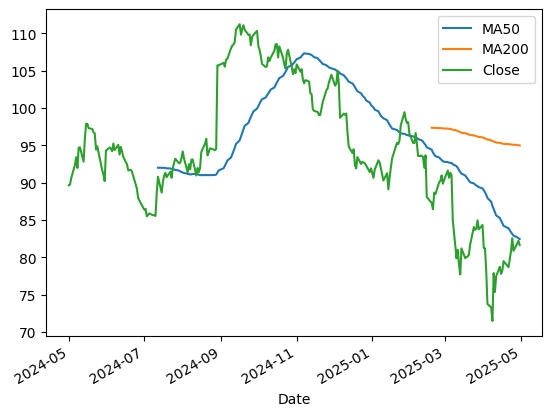

In [ ]:
df_tck[['MA50','MA200','Close']].plot()

In [ ]:
# CODE HERE
# Use as many coding cells as you need

# define a function that detects golden and death crosses in the last 14 days for all stocks

def GDCross(df_close, df_ma50, df_ma200,tk, v_days=14):
  #1: filter dfs with the ticker data
  df_tck_c=df_close[tk]
  df_tck_50=df_ma50[tk]
  df_tck_200=df_ma200[tk]
  #2: join the 3 DF & rename columns
  df_tck= pd.concat([df_tck_c, df_tck_50, df_tck_200], axis=1)
  df_tck.columns = ['Close', 'MA50', 'MA200']
  #3: Get the difference between MA200 and MA50
  df_tck['Difference']=df_tck['MA50']-df_tck['MA200']
  #4: Get the previous value
  df_tck['Diff_prev'] = df_tck['Difference'].shift(1)
  #5: Get the signal
  df_tck['Signal'] = (df_tck['Diff_prev'] * df_tck['Difference']) < 0
  #6: Get the type
  df_tck['Type'] = np.where(
    (df_tck['Signal']) & ((df_tck['MA50']-df_tck['MA50'].shift(v_days)) > 0),
    'Golden Cross',
    np.where(
        (df_tck['Signal']) & ((df_tck['MA50']-df_tck['MA50'].shift(v_days)) < 0),
        'Death Cross',
        'Trend'
    )
  )

  df_tck['Ticker'] = tk

  return df_tck

In [ ]:
df_all=pd.DataFrame()
for t in ticker_list:
  df_golden_cross_14d=GDCross(df_close, df_ma50, df_ma200,t)
  df_all=pd.concat([df_all, df_golden_cross_14d])

df_all[ (df_all['Type']=='Golden Cross') | (df_all['Type']=='Death Cross')]

,Close,MA50,MA200,Difference,Diff_prev,Signal,Type,Ticker
Date,,,,,,,,
2025-04-10,285.220001,340.768491,341.017397,-0.248906,1.415030,True,Death Cross,ACN
2025-03-25,120.001801,135.354380,135.462607,-0.108227,0.168077,True,Death Cross,A
2025-04-21,255.945343,291.398997,291.668273,-0.269277,1.148338,True,Death Cross,APD
2025-02-27,139.449997,135.599102,135.558675,0.040426,-0.037174,True,Golden Cross,ABNB
2025-04-04,106.660004,133.069001,133.096425,-0.027424,0.289976,True,Death Cross,ABNB
...,...,...,...,...,...,...,...,...
2025-04-22,85.724434,99.227853,99.662162,-0.434310,0.001063,True,Death Cross,DIS
2025-04-28,339.880005,358.544401,358.888200,-0.343800,0.698650,True,Death Cross,WAT
2025-02-25,219.933411,313.227207,313.678575,-0.451367,0.788332,True,Death Cross,WST


In [ ]:
# use the display function to show as many intermediary results
# for example display(df_golden_cross_14d)
df_gc=df_all[(df_all['Type']=='Golden Cross')]

for t in df_gc['Ticker'].unique():
  df_golden_cross_14d=GDCross(df_close, df_ma50, df_ma200,t)
  display(df_golden_cross_14d)

,Close,MA50,MA200,Difference,Diff_prev,Signal,Type,Ticker
Date,,,,,,,,
2024-05-01,156.160004,NaN,NaN,NaN,NaN,False,Trend,ABNB
2024-05-02,158.330002,NaN,NaN,NaN,NaN,False,Trend,ABNB
2024-05-03,159.710007,NaN,NaN,NaN,NaN,False,Trend,ABNB
2024-05-06,162.000000,NaN,NaN,NaN,NaN,False,Trend,ABNB
2024-05-07,159.809998,NaN,NaN,NaN,NaN,False,Trend,ABNB
...,...,...,...,...,...,...,...,...
2025-04-24,121.709999,128.497001,130.701575,-2.204575,-2.099625,False,Trend,ABNB
2025-04-25,122.510002,128.136801,130.551875,-2.415075,-2.204575,False,Trend,ABNB
2025-04-28,123.300003,127.782001,130.409175,-2.627174,-2.415075,False,Trend,ABNB


,Close,MA50,MA200,Difference,Diff_prev,Signal,Type,Ticker
Date,,,,,,,,
2024-05-01,100.889999,NaN,NaN,NaN,NaN,False,Trend,AKAM
2024-05-02,99.739998,NaN,NaN,NaN,NaN,False,Trend,AKAM
2024-05-03,99.669998,NaN,NaN,NaN,NaN,False,Trend,AKAM
2024-05-06,101.080002,NaN,NaN,NaN,NaN,False,Trend,AKAM
2024-05-07,101.669998,NaN,NaN,NaN,NaN,False,Trend,AKAM
...,...,...,...,...,...,...,...,...
2025-04-24,79.199997,81.2104,93.59010,-12.37970,-12.00480,False,Trend,AKAM
2025-04-25,79.790001,80.7850,93.52665,-12.74165,-12.37970,False,Trend,AKAM
2025-04-28,80.180000,80.3954,93.45865,-13.06325,-12.74165,False,Trend,AKAM


,Close,MA50,MA200,Difference,Diff_prev,Signal,Type,Ticker
Date,,,,,,,,
2024-05-01,73.828560,NaN,NaN,NaN,NaN,False,Trend,AIG
2024-05-02,76.058716,NaN,NaN,NaN,NaN,False,Trend,AIG
2024-05-03,76.428780,NaN,NaN,NaN,NaN,False,Trend,AIG
2024-05-06,77.879837,NaN,NaN,NaN,NaN,False,Trend,AIG
2024-05-07,78.181732,NaN,NaN,NaN,NaN,False,Trend,AIG
...,...,...,...,...,...,...,...,...
2025-04-24,82.017570,80.652856,75.280895,5.371962,5.278814,False,Trend,AIG
2025-04-25,80.794022,80.746957,75.314013,5.432944,5.371962,False,Trend,AIG
2025-04-28,81.500298,80.864291,75.349634,5.514657,5.432944,False,Trend,AIG


,Close,MA50,MA200,Difference,Diff_prev,Signal,Type,Ticker
Date,,,,,,,,
2024-05-01,169.839096,NaN,NaN,NaN,NaN,False,Trend,AMT
2024-05-02,172.528259,NaN,NaN,NaN,NaN,False,Trend,AMT
2024-05-03,174.545135,NaN,NaN,NaN,NaN,False,Trend,AMT
2024-05-06,171.615875,NaN,NaN,NaN,NaN,False,Trend,AMT
2024-05-07,174.103333,NaN,NaN,NaN,NaN,False,Trend,AMT
...,...,...,...,...,...,...,...,...
2025-04-24,209.263031,206.049297,204.713803,1.335494,1.053580,False,Trend,AMT
2025-04-25,209.173737,206.502661,204.810850,1.691811,1.335494,False,Trend,AMT
2025-04-28,209.649979,206.956299,204.906356,2.049943,1.691811,False,Trend,AMT


,Close,MA50,MA200,Difference,Diff_prev,Signal,Type,Ticker
Date,,,,,,,,
2024-05-01,121.554016,NaN,NaN,NaN,NaN,False,Trend,AWK
2024-05-02,122.360359,NaN,NaN,NaN,NaN,False,Trend,AWK
2024-05-03,125.080551,NaN,NaN,NaN,NaN,False,Trend,AWK
2024-05-06,126.537819,NaN,NaN,NaN,NaN,False,Trend,AWK
2024-05-07,128.063080,NaN,NaN,NaN,NaN,False,Trend,AWK
...,...,...,...,...,...,...,...,...
2025-04-24,145.167801,140.074006,135.404767,4.669239,4.343713,False,Trend,AWK
2025-04-25,143.110168,140.450743,135.481740,4.969002,4.669239,False,Trend,AWK
2025-04-28,143.408371,140.796664,135.552828,5.243836,4.969002,False,Trend,AWK


...

,Close,MA50,MA200,Difference,Diff_prev,Signal,Type,Ticker
Date,,,,,,,,
2024-05-01,67.790001,NaN,NaN,NaN,NaN,False,Trend,UBER
2024-05-02,68.570000,NaN,NaN,NaN,NaN,False,Trend,UBER
2024-05-03,69.230003,NaN,NaN,NaN,NaN,False,Trend,UBER
2024-05-06,71.510002,NaN,NaN,NaN,NaN,False,Trend,UBER
2024-05-07,70.430000,NaN,NaN,NaN,NaN,False,Trend,UBER
...,...,...,...,...,...,...,...,...
2025-04-24,78.099998,74.2036,71.33125,2.87235,2.88360,False,Trend,UBER
2025-04-25,77.750000,74.1716,71.36340,2.80820,2.87235,False,Trend,UBER
2025-04-28,78.330002,74.1324,71.40870,2.72370,2.80820,False,Trend,UBER


,Close,MA50,MA200,Difference,Diff_prev,Signal,Type,Ticker
Date,,,,,,,,
2024-05-01,36.140545,NaN,NaN,NaN,NaN,False,Trend,VZ
2024-05-02,35.891613,NaN,NaN,NaN,NaN,False,Trend,VZ
2024-05-03,35.854736,NaN,NaN,NaN,NaN,False,Trend,VZ
2024-05-06,36.260403,NaN,NaN,NaN,NaN,False,Trend,VZ
2024-05-07,36.241959,NaN,NaN,NaN,NaN,False,Trend,VZ
...,...,...,...,...,...,...,...,...
2025-04-24,42.128819,42.255153,40.068763,2.186390,2.147331,False,Trend,VZ
2025-04-25,41.243137,42.294924,40.084595,2.210328,2.186390,False,Trend,VZ
2025-04-28,41.715500,42.334263,40.100705,2.233558,2.210328,False,Trend,VZ


,Close,MA50,MA200,Difference,Diff_prev,Signal,Type,Ticker
Date,,,,,,,,
2024-05-01,402.140015,NaN,NaN,NaN,NaN,False,Trend,VRTX
2024-05-02,400.160004,NaN,NaN,NaN,NaN,False,Trend,VRTX
2024-05-03,401.079987,NaN,NaN,NaN,NaN,False,Trend,VRTX
2024-05-06,402.500000,NaN,NaN,NaN,NaN,False,Trend,VRTX
2024-05-07,410.239990,NaN,NaN,NaN,NaN,False,Trend,VRTX
...,...,...,...,...,...,...,...,...
2025-04-24,492.470001,487.7650,471.188450,16.576550,15.884449,False,Trend,VRTX
2025-04-25,493.839996,488.5778,471.227701,17.350099,16.576550,False,Trend,VRTX
2025-04-28,496.489990,489.2560,471.252050,18.003949,17.350099,False,Trend,VRTX


,Close,MA50,MA200,Difference,Diff_prev,Signal,Type,Ticker
Date,,,,,,,,
2024-05-01,26.978466,NaN,NaN,NaN,NaN,False,Trend,VICI
2024-05-02,26.885118,NaN,NaN,NaN,NaN,False,Trend,VICI
2024-05-03,26.885118,NaN,NaN,NaN,NaN,False,Trend,VICI
2024-05-06,27.118492,NaN,NaN,NaN,NaN,False,Trend,VICI
2024-05-07,27.585251,NaN,NaN,NaN,NaN,False,Trend,VICI
...,...,...,...,...,...,...,...,...
2025-04-24,32.025124,31.116304,30.340597,0.775707,0.747538,False,Trend,VICI
2025-04-25,31.788342,31.172114,30.368601,0.803513,0.775707,False,Trend,VICI
2025-04-28,31.808073,31.215858,30.395519,0.820339,0.803513,False,Trend,VICI


,Close,MA50,MA200,Difference,Diff_prev,Signal,Type,Ticker
Date,,,,,,,,
2024-05-01,16.210674,NaN,NaN,NaN,NaN,False,Trend,WBA
2024-05-02,16.388300,NaN,NaN,NaN,NaN,False,Trend,WBA
2024-05-03,16.650063,NaN,NaN,NaN,NaN,False,Trend,WBA
2024-05-06,16.135883,NaN,NaN,NaN,NaN,False,Trend,WBA
2024-05-07,16.220022,NaN,NaN,NaN,NaN,False,Trend,WBA
...,...,...,...,...,...,...,...,...
2025-04-24,11.030000,10.8854,9.988516,0.896884,0.867353,False,Trend,WBA
2025-04-25,11.010000,10.9162,9.992426,0.923774,0.896884,False,Trend,WBA
2025-04-28,10.970000,10.9406,9.993909,0.946691,0.923774,False,Trend,WBA


In [ ]:
# use the display function to show as many intermediary results
# for example display(df_death_cross_14d)
df_dc=df_all[ (df_all['Type']=='Death Cross')]
for t in df_dc['Ticker'].unique():
  df_death_cross_14d=GDCross(df_close, df_ma50, df_ma200,t)
  display(df_death_cross_14d)


Output hidden; open in https://colab.research.google.com to view.

#### Golden crosses
List the first top companies in alphabetical order (by there symbol or ticker) that had a golden cross in the last 14 days:

In [ ]:
l_gc=df_gc['Ticker'].unique()
top10_gc=sorted(l_gc)[:10]
top10_gc

['ABNB', 'AIG', 'AKAM', 'AMGN', 'AMT', 'AWK', 'BDX', 'CB', 'CI', 'CSGP']

YOUR WRITTEN RESPONSE HERE

#### Death crosses
List the first 10 companies in alphabetical order (by there symbol or ticker) that had a death cross in the last 14 days:

In [ ]:
l_dc=df_dc['Ticker'].unique()
top10_dc=sorted(l_dc)[:10]
top10_dc

['A', 'AAPL', 'ABNB', 'ACN', 'ADSK', 'ALLE', 'AME', 'AMP', 'AMZN', 'ANET']

In [ ]:
df_gc

,Close,MA50,MA200,Difference,Diff_prev,Signal,Type,Ticker
Date,,,,,,,,
2025-02-27,139.449997,135.599102,135.558675,0.040426,-0.037174,True,Golden Cross,ABNB
2025-02-24,77.650002,96.119600,96.375200,-0.255600,0.056650,True,Golden Cross,AKAM
2025-03-04,79.049004,73.958387,73.908778,0.049608,-0.112834,True,Golden Cross,AIG
2025-04-21,216.287735,204.521144,204.356835,0.164310,-0.276324,True,Golden Cross,AMT
2025-04-04,146.350693,134.488794,134.234415,0.254379,-0.162980,True,Golden Cross,AWK
2025-04-04,291.811157,300.509399,300.316490,0.192908,-0.188505,True,Golden Cross,AMGN
2025-02-21,225.042068,229.810871,229.683146,0.127725,-0.060619,True,Golden Cross,BDX
2025-03-20,294.119995,275.105739,274.848832,0.256907,-0.162043,True,Golden Cross,CB
2025-04-30,338.409912,318.984338,318.720255,0.264084,-0.618534,True,Golden Cross,CI


YOUR WRITTEN RESPONSE HERE

### Visualization of the results
(in alphabetical order)

#### Compute the volatility of every stock and print it in the title of each plot

In [ ]:
# CODE HERE
# Use as many coding cells as you need

# Compute the volatility of every stock in the S&P 500

volatility = df_close.pct_change().rolling(window=14).std() * np.sqrt(14)

num_tickers = len(ticker_list)

rows = 25
cols = 20
fig, axes = plt.subplots(rows, cols, figsize=(60, 100))
axes = axes.ravel()

for i, t in enumerate(ticker_list):
    if i >= len(axes):
        break
    df_vol_t = volatility[t].dropna()
    vol_value = df_vol_t.iloc[-1] if len(df_vol_t) > 0 else np.nan

    axes[i].plot(df_close[t])
    axes[i].set_title(f"{t} | Vol: {vol_value:.2%}" if not np.isnan(vol_value) else f"{t} | Vol: N/A")


plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

#### Plot top 10 stocks that had Golden Crosses in the last 14 days

- You should have 10 plots (use a for loop) for every stock in the top 10 (in alphabetical order)
- For each plot, put the volatility of the stock in the title of the plot

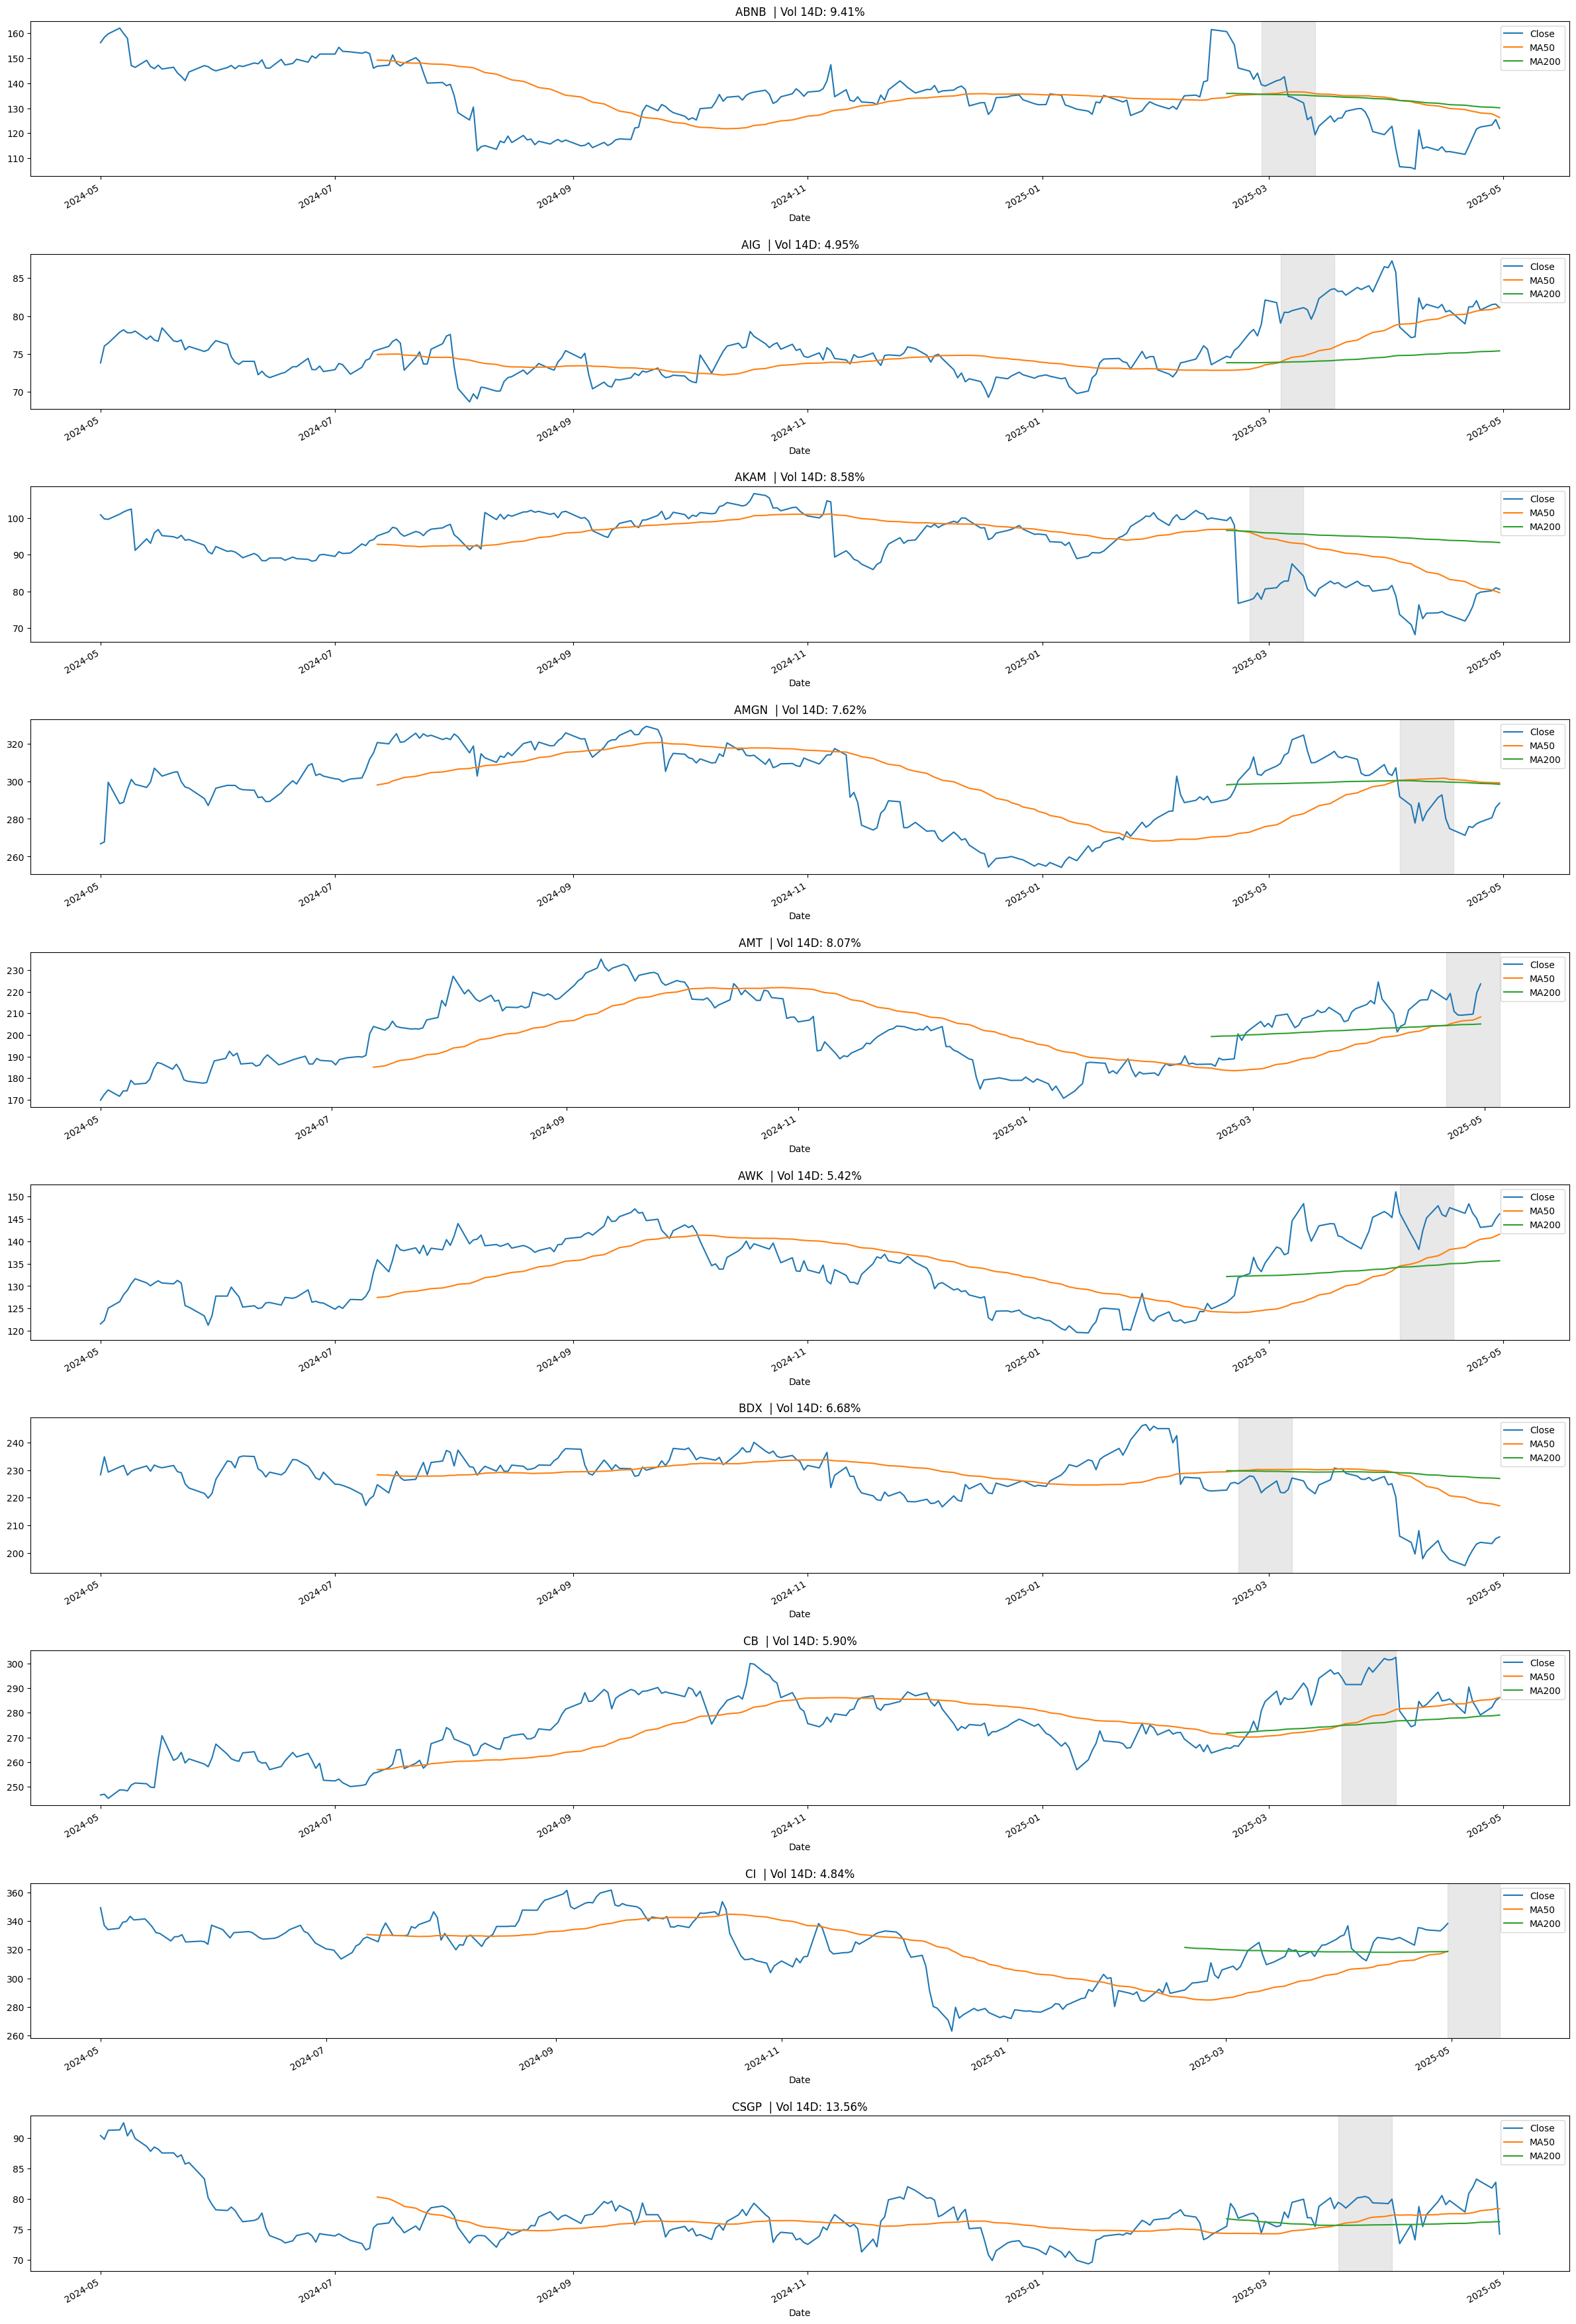

In [ ]:
# CODE HERE
# Visualize the results here

df_plt=pd.DataFrame()
for t in l_gc:
  df_golden_cross_14d=GDCross(df_close, df_ma50, df_ma200,t)
  #1: select the columns I'm going to chart
  df=df_golden_cross_14d[['Close','MA50','MA200','Ticker','Type']]
  df_plt= pd.concat([df_plt,df])

fig, axes = plt.subplots(10,1, figsize=(30,50))
plt.subplots_adjust(hspace=0.5)
axes = axes.ravel()
for i, t in enumerate(top10_gc):
    df_t = df_plt.query('Ticker == @t')[['MA50', 'MA200' , 'Close', 'Type']]
    vol= df_t.Close.pct_change().rolling(window=14).std() * np.sqrt(14)
    SignalDate=df_t[df_t['Type']=='Golden Cross'].index
    vol_value = vol.iloc[-1] if len(vol) > 0 else np.nan
    df_t.plot(ax=axes[i], y=['Close', 'MA50', 'MA200'], title=f'{t}  | Vol 14D: {vol_value:.2%}')
    for date in SignalDate:
      axes[i].axvspan(date, date + pd.Timedelta(days=14), color='lightgray', alpha=0.5)

### Plot top 10 stocks that had Death Crosses in the last 14 days

You should have 10 plots (use a for loop) for every stock in the top 10 (in alphabetical order)
For each plot, put the volatility of the stock in the title of the plot

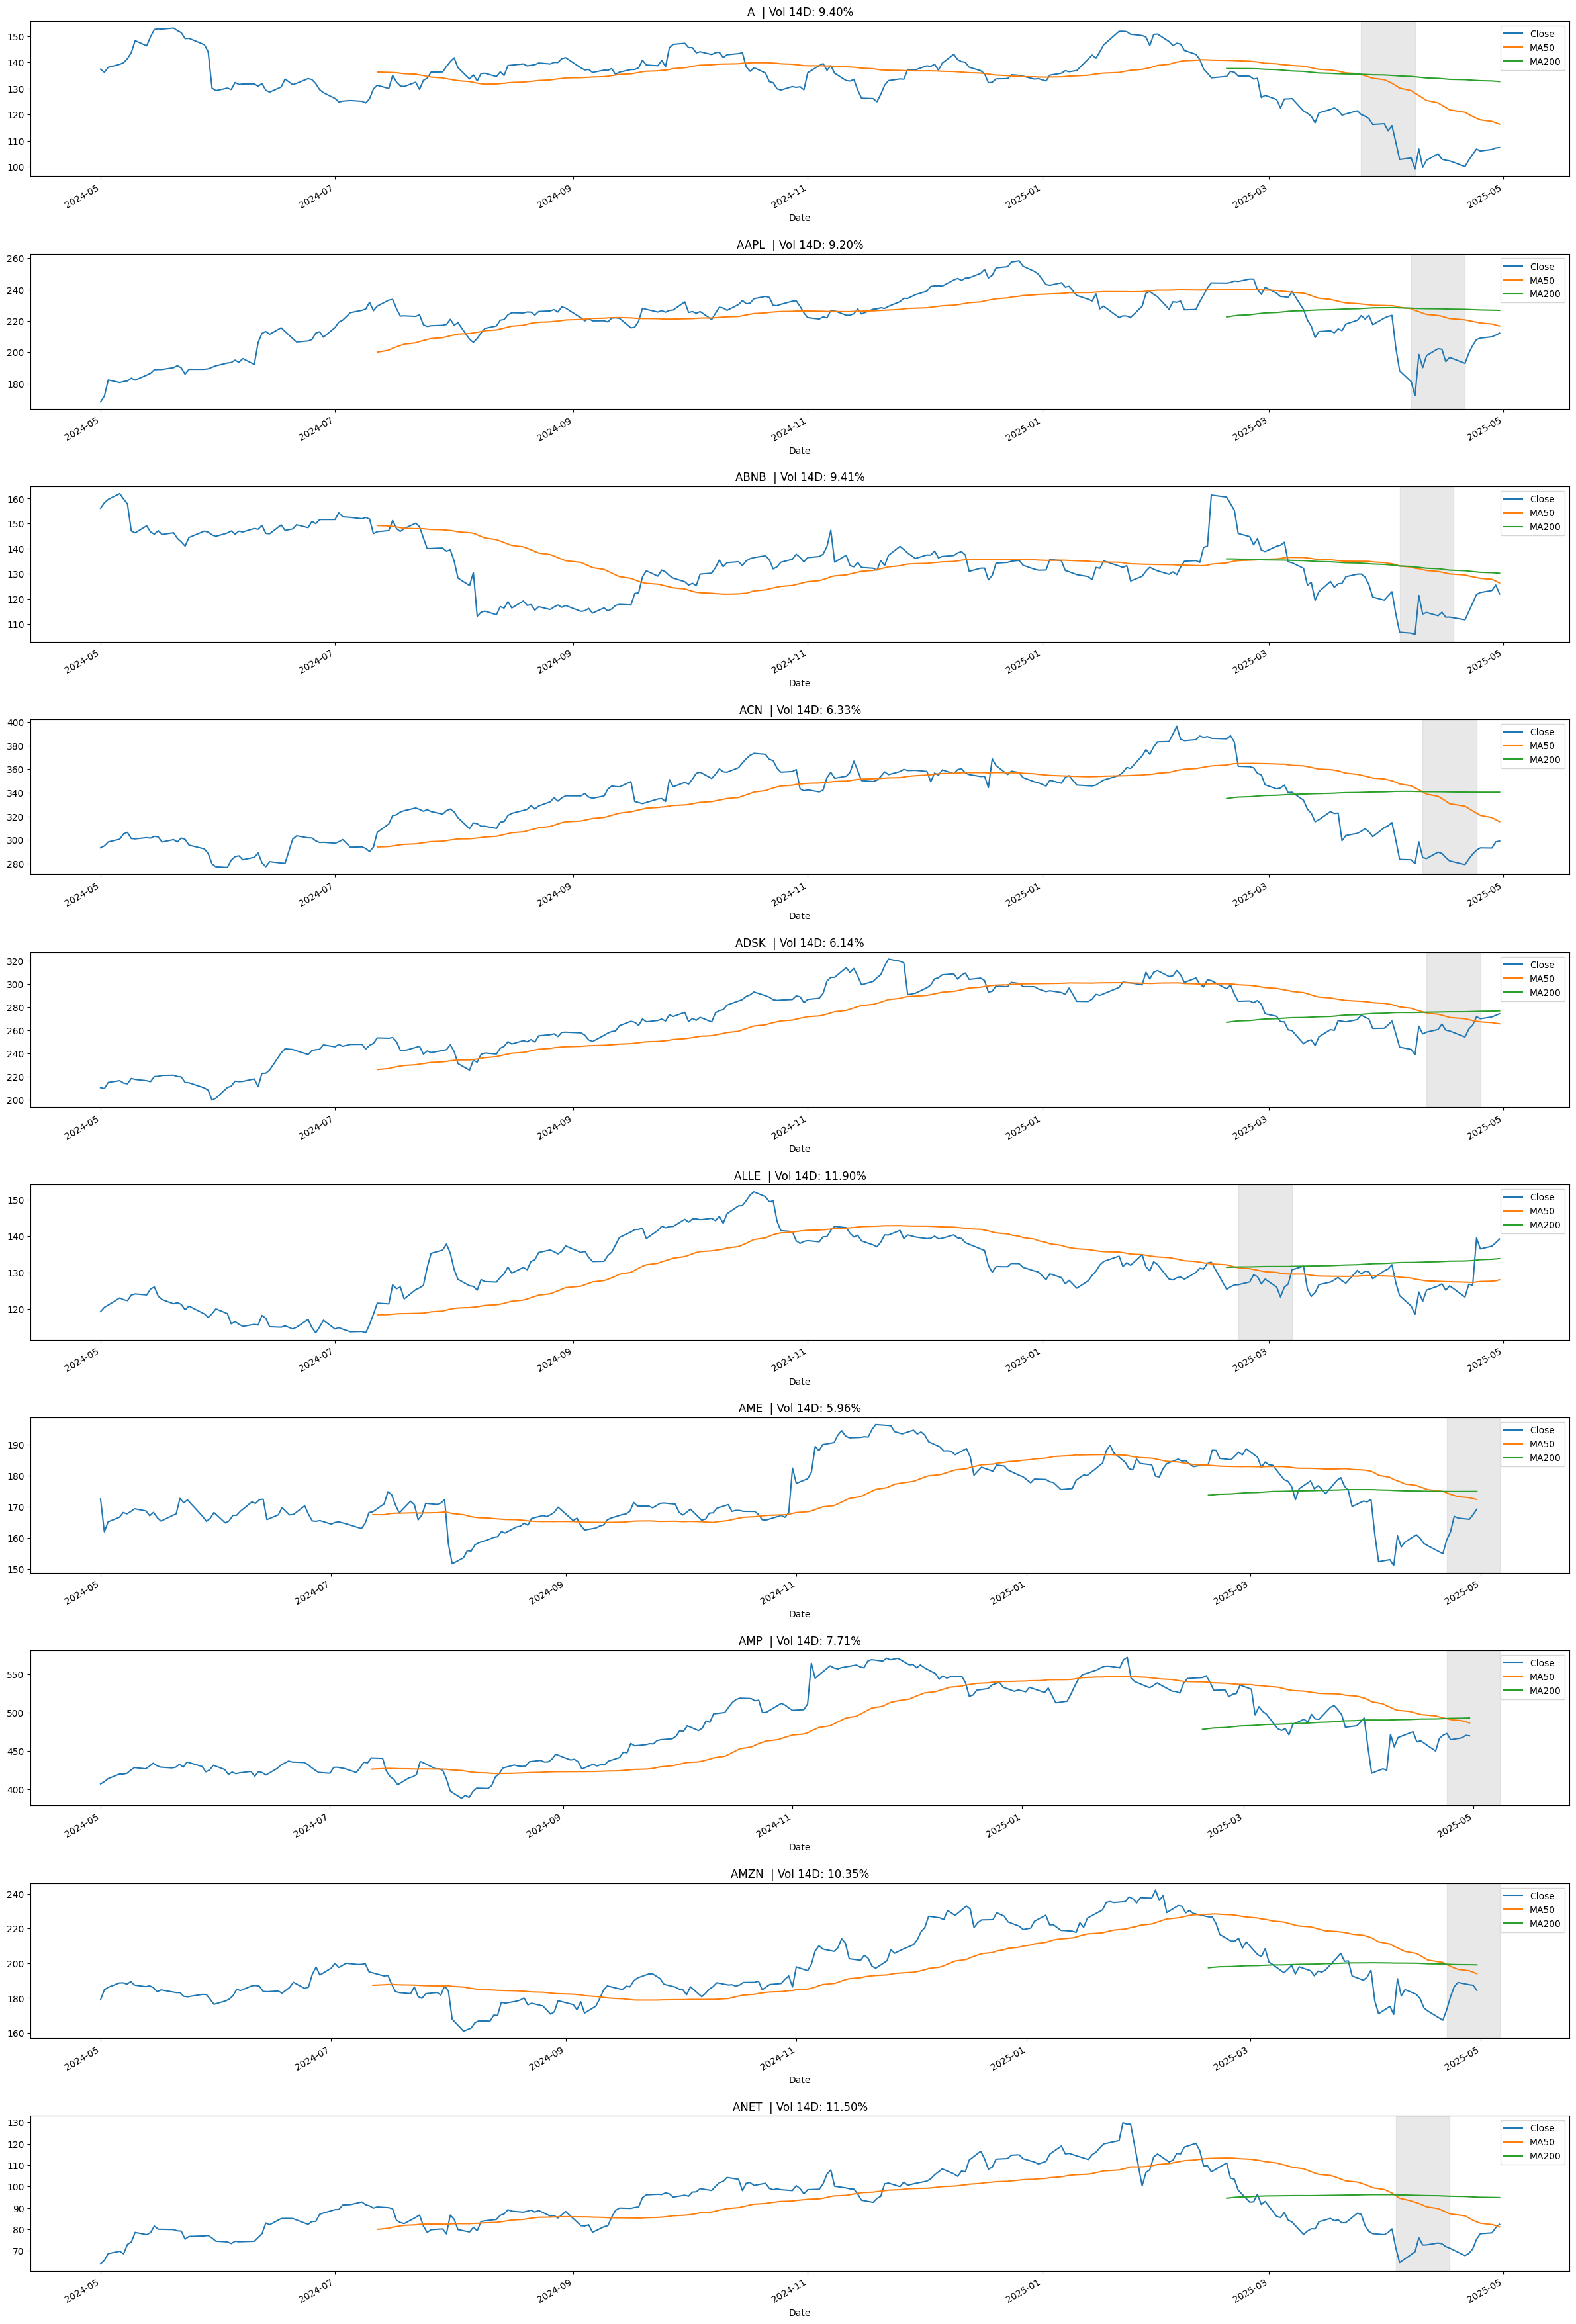

In [ ]:
# CODE HERE
# Visualize the results here
#1: select the columns I'm going to chart
df_plt=pd.DataFrame()
for t in l_dc:
  df_death_cross_14d=GDCross(df_close, df_ma50, df_ma200,t)
  df=df_death_cross_14d[['Close','MA50','MA200','Ticker','Type']]
  df_plt= pd.concat([df_plt,df])
#2: for loop to do the plot of only the symbols that are in the top 10

fig, axes = plt.subplots(10,1, figsize=(30,50))
plt.subplots_adjust(hspace=0.5)
axes = axes.ravel()
for i, t in enumerate(top10_dc):
    df_t = df_plt.query('Ticker == @t')[['MA50', 'MA200' , 'Close', 'Type']]
    vol= df_t.Close.pct_change().rolling(window=14).std() * np.sqrt(14)
    SignalDate=df_t[df_t['Type']=='Death Cross'].index
    vol_value = vol.iloc[-1] if len(vol) > 0 else np.nan
    df_t.plot(ax=axes[i], y=['Close', 'MA50', 'MA200'], title=f'{t}  | Vol 14D: {vol_value:.2%}')
    for date in SignalDate:
      axes[i].axvspan(date, date + pd.Timedelta(days=14), color='lightgray', alpha=0.5)

## Question section

### Understanding concepts

#### What is a Golden Cross and what does it typically signal to investors?

Is when the MA50 cross from lower side the MA200, these means that is the moment of a buying trades, also it is a signal to start trading cause the the stock could increase its price.



#### What is a Death Cross and how might market participants react to it?

It's when the MA50 crosses the MA200 from above, the reaction is a selling trade.


#### Why might moving averages (MA50, MA200) be used as indicators in technical analysis?

Because it shows the trend of the sotck proce, it only considers the 50 or 200 days; this means that if the stock has volatility, the trend will "smooth" that volatility.



#### Why are the last 14 days used to check for crosses? What are the implications of this choice?

I think that is only for confirmation that the golden/death cross will continue, otherwise, it will be a trade in which you'll loose money.



#### How does volatility (e.g., measured using percentage change standard deviation) help contextualize the price movement around crosses?

If you have a high volatility, it could confirm that the trade is going to be good and very profitable.

### Backtesting and evaluation

#### How would you measure whether Golden Crosses actually lead to profitable trades?

With the difference between the MA's, cause if it changes the sing (eg., -0.5 ti 0.5) of the difference, it means that it will be a powerfull movement.


#### What are the risks of using only technical indicators like moving averages without incorporating fundamentals?

If you don´t consider a fundamental analysis, which causes volatility, you will miss good trade oportunities.

#### How would you improve this strategy to reduce false signals (e.g., a Golden Cross that doesn’t lead to a price increase)?

Based on my experince, specially in FOREX, I preferd to use EMA. This means that in case of any volatility, the trend for the 50D will be smooth more and give more accuracy when trading.

### AI Integration


#### Could sentiment from news (future project part) help validate or invalidate these technical signals?

Absolutly, cause it analyzes how the market are taking the news. So if it's positve, I thik will mean that the stock price could be going in a posotive trend, if negative it could mean that the stock price is going down, and if it's neutral, the stock price will stucked.


### Critical thinking

#### From a trading perspective, is this strategy actionable on its own?

No, cause you should consider other variables, like inflation, quarterly calls, financial statements, among others. Also, to be actionable of it own, the algorithm should be able to predict the value of the next candle.

#### Based on the volatility observed post-Golden Cross, do these crosses consistently predict upward movement?

Not necesrily, cause this golden crosses could be only for a short-term period, so if you are thinking in long or middle term, using technical analysis, the best option is to search for other figueres, like triangles, double celling, among others, just to be sure that you are having a good trade.



#### If you had to present this analysis to a portfolio manager, what conclusions would you emphasize? What caveats would you include?

Conclusions in 2 bullet points:

YOUR WRITTEN RESPONSE HERE


Caveats in 2 or 3 bullet points:

YOUR WRITTEN REPSONSE HERE